# MNIST Classification with PyTorch

A simple Feedforward Neural Network to classify handwritten digits from the MNIST dataset.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading and Preparation
We use standard transformations to convert images to tensors and normalize them.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.27MB/s]


## 2. Model Architecture
A simple neural network with one hidden layer and ReLU activation.

In [5]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleNN().to(device)
print(model)

SimpleNN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 3. Training the Model
We use Cross-Entropy Loss and the Adam optimizer, training the model for 3 epochs.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
epochs = 3
loss_history = []  # List to store loss values for plotting

for epoch in range(epochs):
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        # Save the loss value
        loss_history.append(loss.item())

    print(f"Epoch {epoch+1} completed. Loss: {loss.item():.4f}")

Epoch 1 completed. Loss: 0.1754
Epoch 2 completed. Loss: 0.0134
Epoch 3 completed. Loss: 0.0444


## 4. Evaluation
Testing the trained model's performance on unseen test data.

In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        preds = output.argmax(dim=1)
        correct += (preds == target).sum().item()
        total += target.size(0)

accuracy = 100 * correct / total
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 97.52%


### 1.1. Data Visualization
Let's look at some sample images from the MNIST dataset to understand what the model is training on.

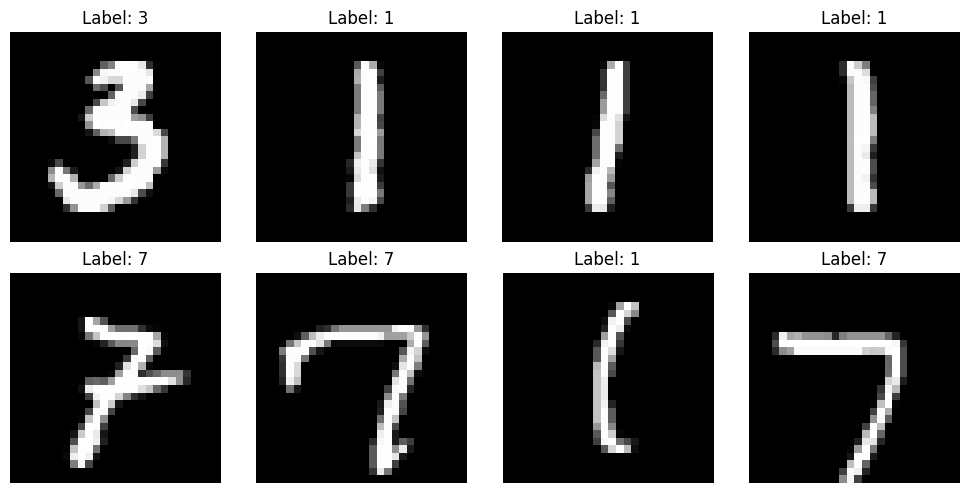

In [11]:
import matplotlib.pyplot as plt

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Plot a grid of sample images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    # Unnormalize the image back to its original range for proper display
    img = images[i].numpy().squeeze() * 0.3081 + 0.1307
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.2. Training Loss Curve
Plotting the loss history to verify that the model is converging properly.

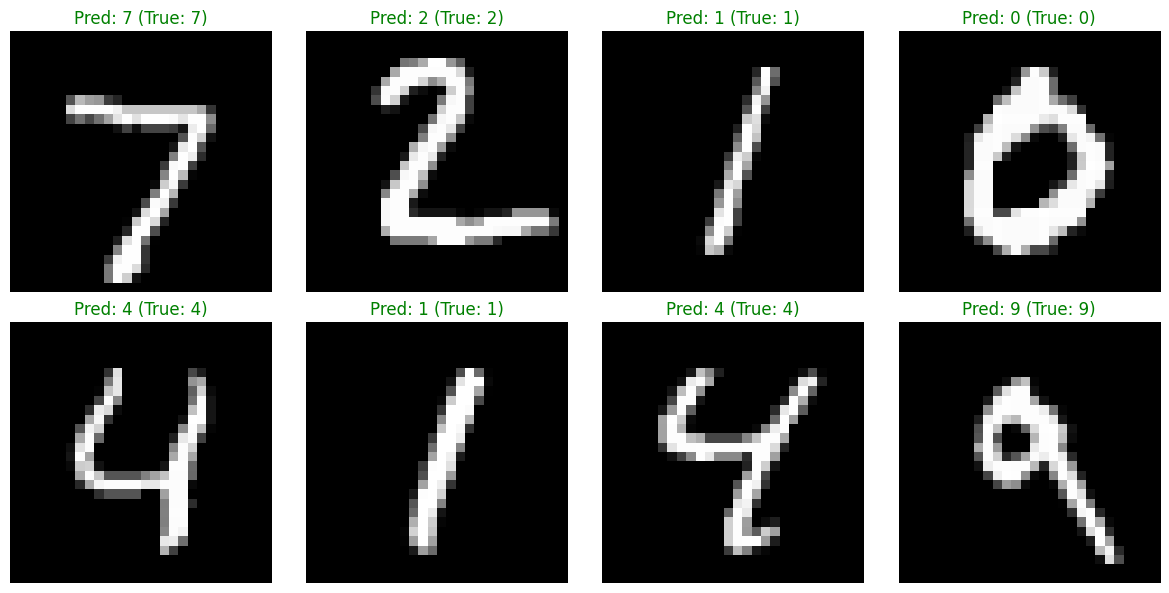

In [12]:
model.eval()
# Get a batch of test data
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Move to device for prediction, then move results back to CPU
images_dev = images.to(device)
with torch.no_grad():
    output = model(images_dev)
    preds = output.argmax(dim=1).cpu().numpy()

# Plot test images with predictions
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().squeeze() * 0.3081 + 0.1307
    true_label = labels[i].item()
    pred_label = preds[i]

    ax.imshow(img, cmap='gray')

    # Color green if correct, red if wrong
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"Pred: {pred_label} (True: {true_label})", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()